# 01 - RAE2822 Cp Surrogate Model

This notebook is the first clean ML notebook for the project.

Goal:
1. Load RAE2822 CFD surface data.
2. Visualize the pressure coefficient distribution.
3. Define a fair ML validation setup.
4. Compare simple baseline models before using a neural network.


## 1. Imports

Keep imports in one place so the notebook is easy to scan.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

## 2. Connect The Notebook To The Project

The notebook may be opened from different folders. This cell finds the project root by looking for the `cfd_ml` package.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "cfd_ml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from cfd_ml.data import load_rae2822_surface_data
from cfd_ml.paths import FIGURES_DIR, METRICS_DIR
from cfd_ml.tuning import (
    build_cp_tuning_specs,
    encode_params_for_csv,
    tune_randomized_search_specs,
)

print(PROJECT_ROOT)


/Users/pun/Desktop/CFD-ML/CFD-Machine-learning


## 3. Load RAE2822 Surface Data

Each case is one angle of attack. Each row is one surface point on the airfoil.

In [3]:
raw_df = load_rae2822_surface_data()

cp_df = raw_df[["AoA", "x", "y", "sin_AoA", "cos_AoA", "Pressure_Coefficient"]].copy()
cp_df = cp_df.dropna().reset_index(drop=True)

cp_df.head()

,AoA,x,y,sin_AoA,cos_AoA,Pressure_Coefficient
0,0.0,0.985397,0.000943,0.0,1.0,0.262408
1,0.0,0.969573,0.001489,0.0,1.0,0.279663
2,0.0,0.952680,0.001679,0.0,1.0,0.293002
3,0.0,0.934996,0.001511,0.0,1.0,0.295781
4,0.0,0.916822,0.000923,0.0,1.0,0.292556


In [4]:
print("Rows:", len(cp_df))
print("AoA cases:", cp_df["AoA"].nunique())
print("AoA range:", cp_df["AoA"].min(), "to", cp_df["AoA"].max())

cp_df.groupby("AoA").size().head()

Rows: 4032
AoA cases: 21
AoA range: 0.0 to 20.0


AoA
0.0    192
1.0    192
2.0    192
3.0    192
4.0    192
dtype: int64

## 4. Visualize One CFD Case

For aerodynamics plots, Cp is usually shown with the y-axis inverted. Lower Cp means stronger suction on the airfoil surface.

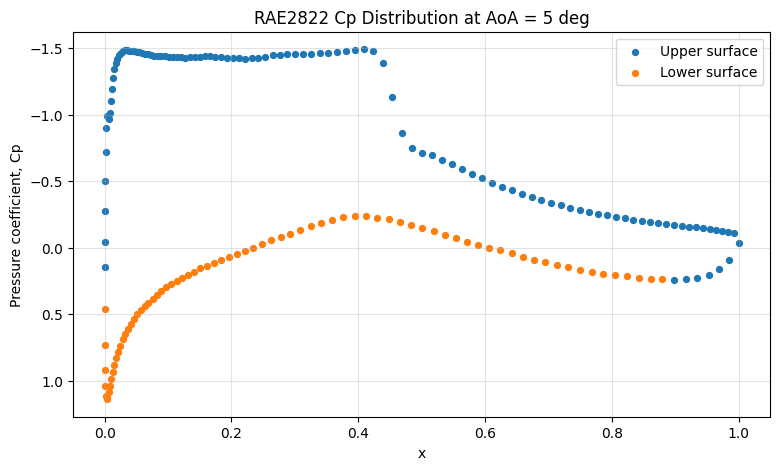

In [5]:
def plot_cp_distribution(data, aoa):
    case = data[data["AoA"] == aoa].copy()
    if case.empty:
        raise ValueError(f"AoA {aoa} not found in dataset")

    upper = case[case["y"] > 0].sort_values("x")
    lower = case[case["y"] <= 0].sort_values("x")

    plt.figure(figsize=(9, 5))
    plt.scatter(upper["x"], upper["Pressure_Coefficient"], s=18, label="Upper surface")
    plt.scatter(lower["x"], lower["Pressure_Coefficient"], s=18, label="Lower surface")
    plt.gca().invert_yaxis()
    plt.xlabel("x")
    plt.ylabel("Pressure coefficient, Cp")
    plt.title(f"RAE2822 Cp Distribution at AoA = {aoa:g} deg")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.show()


plot_cp_distribution(cp_df, aoa=5.0)

## 5. Define The ML Problem

We predict `Pressure_Coefficient` from surface position and angle of attack.

Features:
- `x`, `y`: fixed airfoil surface coordinates
- `sin_AoA`, `cos_AoA`: angle encoded as smooth numeric features

Target:
- `Pressure_Coefficient`

In [6]:
features = ["x", "y", "sin_AoA", "cos_AoA"]
target = "Pressure_Coefficient"

X = cp_df[features]
y = cp_df[target]
groups = cp_df["AoA"]

X.head()

,x,y,sin_AoA,cos_AoA
0,0.985397,0.000943,0.0,1.0
1,0.969573,0.001489,0.0,1.0
2,0.952680,0.001679,0.0,1.0
3,0.934996,0.001511,0.0,1.0
4,0.916822,0.000923,0.0,1.0


## 6. Validation Strategy

A normal random train/test split would leak information because nearby rows from the same AoA would appear in both train and test.

Instead, we use Leave-One-Group-Out validation. Each fold trains on 20 AoA cases and tests on 1 unseen AoA case.

In [7]:
def evaluate_model(model, X, y, groups):
    splitter = LeaveOneGroupOut()
    fold_scores = []
    fold_predictions = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        fold_model = clone(model)
        fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])

        y_true = y.iloc[test_idx]
        y_pred = fold_model.predict(X.iloc[test_idx])
        test_aoa = float(groups.iloc[test_idx].unique()[0])

        fold_scores.append({
            "fold": fold,
            "AoA": test_aoa,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred),
        })

        prediction_frame = cp_df.iloc[test_idx][["AoA", "x", "y"]].copy()
        prediction_frame["y_true"] = y_true.to_numpy()
        prediction_frame["y_pred"] = y_pred
        fold_predictions.append(prediction_frame)

    return pd.DataFrame(fold_scores), pd.concat(fold_predictions, ignore_index=True)

## 7. Compare Baseline Models

Start with simple models before the neural network. This gives us a fair reference point.

In [8]:
models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Polynomial ridge d2": make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1.0),
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient boosting": GradientBoostingRegressor(
        n_estimators=160,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

all_scores = []
all_predictions = {}

for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    scores, predictions = evaluate_model(model, X, y, groups)
    scores["model"] = model_name
    all_scores.append(scores)
    all_predictions[model_name] = predictions

scores_df = pd.concat(all_scores, ignore_index=True)
scores_df.head()

Evaluating Mean baseline...
Evaluating Linear regression...
Evaluating Polynomial ridge d2...
Evaluating Random forest...
Evaluating Gradient boosting...


,fold,AoA,MAE,RMSE,R2,model
0,1,0.0,0.319605,0.437559,-0.127931,Mean baseline
1,2,1.0,0.388569,0.483224,-0.046092,Mean baseline
2,3,2.0,0.487620,0.578077,-0.003817,Mean baseline
3,4,3.0,0.592818,0.690540,-0.002475,Mean baseline
4,5,4.0,0.647859,0.758155,-0.011986,Mean baseline


In [9]:
summary_df = (
    scores_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        RMSE_std=("RMSE", "std"),
    )
    .sort_values("RMSE_mean")
)

summary_df

,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest,0.032728,0.067606,0.980645,0.042943
Gradient boosting,0.114308,0.158207,0.926457,0.050864
Polynomial ridge d2,0.350427,0.448550,0.498352,0.052230
Linear regression,0.400265,0.514382,0.368117,0.063485
Mean baseline,0.556851,0.667911,-0.017590,0.094837


## 8. Tune Classical Model Hyperparameters

The baseline comparison used fixed parameters. This section searches stronger settings for the nonlinear sklearn models while keeping the same Leave-One-AoA-Out validation strategy.

The original baseline CSV files are kept as-is; tuned outputs are saved to separate files in the final section.


In [10]:
cp_tuning_specs = build_cp_tuning_specs(random_state=42)

tuning_results_df, tuned_models = tune_randomized_search_specs(
    cp_tuning_specs,
    X,
    y,
    cv=LeaveOneGroupOut(),
    groups=groups,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    search_n_jobs=1,
)

tuning_results_df


Tuning Polynomial ridge tuned...
Tuning Random forest tuned...
Tuning Gradient boosting tuned...


,model,best_score,best_rmse,best_params,n_iter,cv_splits,scoring
1,Random forest tuned,-0.062083,0.062083,"{'n_estimators': 300, 'min_samples_split': 2, ...",24,21,neg_root_mean_squared_error
2,Gradient boosting tuned,-0.074885,0.074885,"{'subsample': 0.75, 'n_estimators': 220, 'min_...",24,21,neg_root_mean_squared_error
0,Polynomial ridge tuned,-0.338279,0.338279,"{'ridge__alpha': 0.01, 'polynomialfeatures__de...",18,21,neg_root_mean_squared_error


In [11]:
tuned_scores = []
tuned_predictions = {}

for model_name, model in tuned_models.items():
    print(f"Evaluating {model_name}...")
    scores, predictions = evaluate_model(model, X, y, groups)
    scores["model"] = model_name
    tuned_scores.append(scores)
    tuned_predictions[model_name] = predictions

tuned_scores_df = pd.concat(tuned_scores, ignore_index=True)
tuned_summary_df = (
    tuned_scores_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        RMSE_std=("RMSE", "std"),
    )
    .sort_values("RMSE_mean")
)

tuned_comparison_summary = pd.concat([
    summary_df.assign(parameter_source="baseline"),
    tuned_summary_df.assign(parameter_source="tuned"),
]).sort_values("RMSE_mean")

tuned_summary_df


Evaluating Polynomial ridge tuned...
Evaluating Random forest tuned...
Evaluating Gradient boosting tuned...


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.028635,0.062083,0.982564,0.044351
Gradient boosting tuned,0.046010,0.074885,0.979126,0.040535
Polynomial ridge tuned,0.241918,0.338279,0.709052,0.039866


## 9. Plot Baseline Vs Tuned Comparison

Lower RMSE is better. This plot shows whether hyperparameter tuning changed the Cp model ranking.


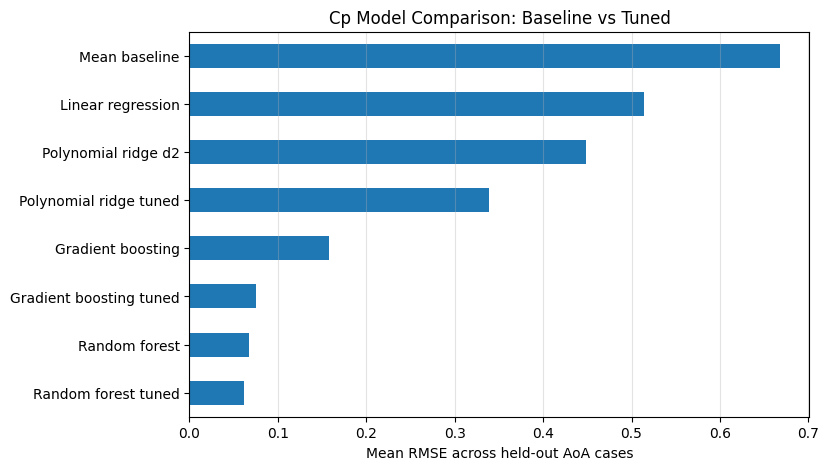

In [12]:
ax = tuned_comparison_summary["RMSE_mean"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8, 5),
)
ax.set_xlabel("Mean RMSE across held-out AoA cases")
ax.set_ylabel("")
ax.set_title("Cp Model Comparison: Baseline vs Tuned")
ax.grid(True, axis="x", alpha=0.35)
plt.show()


## 10. Inspect Tuned Prediction Quality

A metric is useful, but for CFD we also need to inspect whether the predicted Cp curve has the correct shape.


In [13]:
best_model_name = tuned_summary_df.index[0]
best_predictions = tuned_predictions[best_model_name]
best_params = tuning_results_df.loc[
    tuning_results_df["model"] == best_model_name,
    "best_params",
].iloc[0]

print("Best tuned model:", best_model_name)
print("Best tuned parameters:", best_params)


Best tuned model: Random forest tuned
Best tuned parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 20}


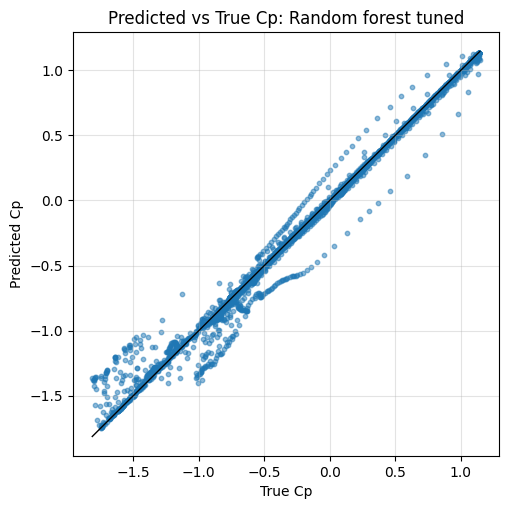

In [14]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(best_predictions["y_true"], best_predictions["y_pred"], s=10, alpha=0.5)

min_value = min(best_predictions["y_true"].min(), best_predictions["y_pred"].min())
max_value = max(best_predictions["y_true"].max(), best_predictions["y_pred"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="black", linewidth=1)

plt.xlabel("True Cp")
plt.ylabel("Predicted Cp")
plt.title(f"Predicted vs True Cp: {best_model_name}")
plt.grid(True, alpha=0.35)
plt.show()

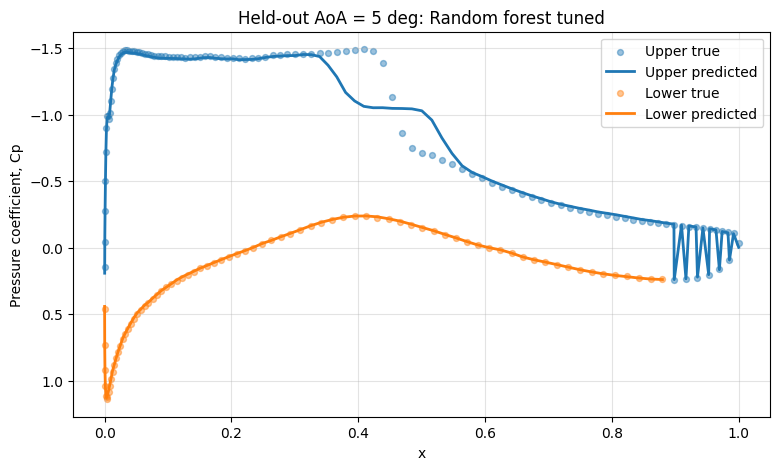

In [15]:
def plot_prediction_for_aoa(predictions, aoa):
    case = predictions[predictions["AoA"] == aoa].copy()
    if case.empty:
        raise ValueError(f"AoA {aoa} not found in predictions")

    upper = case[case["y"] > 0].sort_values("x")
    lower = case[case["y"] <= 0].sort_values("x")

    plt.figure(figsize=(9, 5))

    plt.scatter(upper["x"], upper["y_true"], s=18, alpha=0.45, label="Upper true")
    plt.plot(upper["x"], upper["y_pred"], linewidth=2, label="Upper predicted")

    plt.scatter(lower["x"], lower["y_true"], s=18, alpha=0.45, label="Lower true")
    plt.plot(lower["x"], lower["y_pred"], linewidth=2, label="Lower predicted")

    plt.gca().invert_yaxis()
    plt.xlabel("x")
    plt.ylabel("Pressure coefficient, Cp")
    plt.title(f"Held-out AoA = {aoa:g} deg: {best_model_name}")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.show()


plot_prediction_for_aoa(best_predictions, aoa=5.0)

## 11. Save Metrics For The Report

Baseline files keep the original names. Tuned results use explicit filenames so reports can compare fixed-parameter models against tuned models without mixing the two.


In [16]:
METRICS_DIR.mkdir(parents=True, exist_ok=True)

summary_path = METRICS_DIR / "cp_model_comparison_summary.csv"
fold_path = METRICS_DIR / "cp_model_comparison_by_aoa.csv"
tuning_path = METRICS_DIR / "cp_tuning_results.csv"
tuned_summary_path = METRICS_DIR / "cp_tuned_model_comparison_summary.csv"
tuned_fold_path = METRICS_DIR / "cp_tuned_model_comparison_by_aoa.csv"
combined_summary_path = METRICS_DIR / "cp_baseline_vs_tuned_summary.csv"

summary_df.to_csv(summary_path)
scores_df.to_csv(fold_path, index=False)
encode_params_for_csv(tuning_results_df).to_csv(tuning_path, index=False)
tuned_summary_df.to_csv(tuned_summary_path)
tuned_scores_df.to_csv(tuned_fold_path, index=False)
tuned_comparison_summary.to_csv(combined_summary_path)

print(summary_path)
print(fold_path)
print(tuning_path)
print(tuned_summary_path)
print(tuned_fold_path)
print(combined_summary_path)


/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_model_comparison_summary.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_model_comparison_by_aoa.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_tuning_results.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_tuned_model_comparison_summary.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_tuned_model_comparison_by_aoa.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_baseline_vs_tuned_summary.csv


## Next Step

After this tuned classical-model comparison, the neural-network notebook can compare against `cp_tuned_model_comparison_summary.csv` when that file exists, and fall back to the original baseline table otherwise.
